# ETA Prediction — Random Forest (v2 mejorado)
Mejoras basadas en:
- Li (2017) *Predicting MTA Bus Arrival Times in NYC* — Stanford CS229
- Survey of ETA prediction methods (arxiv 1904.05037)
- AlKheder et al. (2022) *Bus arrival time prediction using ML and GIS*

In [1]:
# ── CELDA 1: sin cambios ─────────────────────────────────────────────────────
# unzip ETA dataset
!unzip "/content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip" -d "/content/drive/MyDrive/Capstone/Datasets/ETA/"

unzip:  cannot find or open /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip, /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip.zip or /content/drive/MyDrive/Capstone/Datasets/mta_1706.csv.zip.ZIP.


In [2]:
# ── CELDA 2: MODIFICADA — imports adicionales ────────────────────────────────
import pandas as pd
import numpy as np                          # NUEVO: necesario para haversine vectorizado
from sklearn.model_selection import train_test_split

print("Librerías cargadas.")

Librerías cargadas.


In [3]:
# ── CELDA 3: sin cambios ─────────────────────────────────────────────────────
path_csv = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/mta_1706.csv"

print("Cargando dataset...")
df = pd.read_csv(path_csv, on_bad_lines='skip', low_memory=False)
print("¡Dataset cargado exitosamente!")
print(df.head())

Cargando dataset...
¡Dataset cargado exitosamente!
        RecordedAtTime  DirectionRef PublishedLineName  \
0  2017-06-01 00:03:34             0                B8   
1  2017-06-01 00:03:43             1               S61   
2  2017-06-01 00:03:49             0              Bx10   
3  2017-06-01 00:03:31             0                Q5   
4  2017-06-01 00:03:22             1               Bx1   

                  OriginName  OriginLat  OriginLong  \
0                 4 AV/95 ST  40.616104  -74.031143   
1  ST GEORGE FERRY/S61 & S91  40.643169  -74.073494   
2     E 206 ST/BAINBRIDGE AV  40.875008  -73.880142   
3           TEARDROP/LAYOVER  40.701748  -73.802399   
4      RIVERDALE AV/W 231 ST  40.881187  -73.909340   

                   DestinationName  DestinationLat  DestinationLong  \
0          BROWNSVILLE ROCKAWAY AV       40.656048       -73.907379   
1                S I MALL YUKON AV       40.575935       -74.167686   
2                 RIVERDALE 263 ST       40.912376      

In [4]:
# ── CELDA 4: sin cambios ─────────────────────────────────────────────────────
print("Tomando muestra de 3,000,000 filas...")
df_sample = df.sample(n=3000000, random_state=42)
print("Muestra tomada.")
df_sample.head()

Tomando muestra de 3,000,000 filas...
Muestra tomada.


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37
1255600,2017-06-06 17:42:56,1,B52,PALMETTO ST/ST NICHOLAS AV,40.700420,-73.909996,DNTWN BKLYN TILLARY ST via GATES,40.693939,-73.990311,NYCT_4528,40.700726,-73.910135,GATES AV/WYCKOFF AV,< 1 stop away,202.0,NaN,17:49:48
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35


In [5]:
# ── CELDA 5: MODIFICADA — más columnas críticas ──────────────────────────────
# ANTES: dropna solo en 3 columnas
# AHORA: incluimos las columnas nuevas que necesitamos para las features

print("Eliminando filas con valores nulos en columnas clave...")
df_processed = df_sample.dropna(subset=[
    'ExpectedArrivalTime',
    'RecordedAtTime',
    'DistanceFromStop',
    'VehicleLocation.Latitude',   # NUEVO: necesario para speed_kmh
    'VehicleLocation.Longitude',  # NUEVO: necesario para speed_kmh
    'VehicleRef',                 # NUEVO: necesario para agrupar por vehículo
    'ArrivalProximityText',       # NUEVO: necesario para proximity_enc
]).copy()

print(f"Filas después de limpiar nulos: {len(df_processed)}")
df_processed.head()

Eliminando filas con valores nulos en columnas clave...
Filas después de limpiar nulos: 2610484


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35
1282111,2017-06-06 19:22:57,0,M7,AV OF THE AMERICAS/W 14 ST,40.737930,-73.996346,HARLEM 147 ST via 6 AV via AMSTERDAM,40.821110,-73.935898,NYCT_6759,40.781203,-73.979741,AMSTERDAM AV/W 77 ST,approaching,113.0,2017-06-06 19:23:40,19:02:37


In [6]:
# ── CELDA 6: sin cambios ─────────────────────────────────────────────────────
print("Convirtiendo columnas de tiempo...")
df_processed['ExpectedArrivalTime'] = pd.to_datetime(df_processed['ExpectedArrivalTime'])
df_processed['RecordedAtTime']      = pd.to_datetime(df_processed['RecordedAtTime'])

Convirtiendo columnas de tiempo...


In [7]:
#imprimir para ver como quedaron las fechas/horas de las columnas
print(df_processed.head())

             RecordedAtTime  DirectionRef PublishedLineName  \
2170987 2017-06-10 16:09:29             0               B35   
5287764 2017-06-24 17:02:27             1           M15-SBS   
4304178 2017-06-20 14:45:31             0               Bx3   
1135968 2017-06-06 09:22:54             0               Q88   
1282111 2017-06-06 19:22:57             0                M7   

                         OriginName  OriginLat  OriginLong  \
2170987      CHURCH AV/MC DONALD AV  40.642651  -73.979584   
5287764               E 126 ST/2 AV  40.803230  -73.932449   
4304178             BROADWAY/179 ST  40.849327  -73.936508   
1135968                 92 ST/59 AV  40.734272  -73.869301   
1282111  AV OF THE AMERICAS/W 14 ST  40.737930  -73.996346   

                                 DestinationName  DestinationLat  \
2170987       BROWNSVILLE M GASTON BL via CHURCH       40.656345   
5287764  SELECT BUS SERVICE SOUTH FERRY via 2 AV       40.702122   
4304178                  RIVERDALE BWAY - 23

In [8]:
# ── CELDA 7: sin cambios ─────────────────────────────────────────────────────
print("Creando el target (y) 'TimeToArrival' (en minutos)...")
df_processed['TimeToArrival'] = (
    df_processed['ExpectedArrivalTime'] - df_processed['RecordedAtTime']
).dt.total_seconds() / 60
df_processed.head()

Creando el target (y) 'TimeToArrival' (en minutos)...


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,TimeToArrival
2170987,2017-06-10 16:09:29,0,B35,CHURCH AV/MC DONALD AV,40.642651,-73.979584,BROWNSVILLE M GASTON BL via CHURCH,40.656345,-73.907188,NYCT_327,40.645069,-73.974039,CHURCH AV/OCEAN PY,at stop,2.0,2017-06-10 16:09:48,16:08:17,0.316667
5287764,2017-06-24 17:02:27,1,M15-SBS,E 126 ST/2 AV,40.803230,-73.932449,SELECT BUS SERVICE SOUTH FERRY via 2 AV,40.702122,-74.013664,NYCT_1268,40.740819,-73.978765,2 AV/E 23 ST,< 1 stop away,420.0,2017-06-24 17:05:00,16:47:57,2.550000
4304178,2017-06-20 14:45:31,0,Bx3,BROADWAY/179 ST,40.849327,-73.936508,RIVERDALE BWAY - 238 ST,40.885086,-73.900436,NYCT_4372,40.856785,-73.909881,UNIVERSITY AV/W 181 ST,approaching,79.0,2017-06-20 14:46:03,14:33:37,0.533333
1135968,2017-06-06 09:22:54,0,Q88,92 ST/59 AV,40.734272,-73.869301,QUEENS VILL JAMAICA AV,40.717922,-73.736382,NYCT_6889,40.740524,-73.786886,188 ST/HORACE HARDING EXP,approaching,58.0,2017-06-06 09:23:18,08:54:35,0.400000
1282111,2017-06-06 19:22:57,0,M7,AV OF THE AMERICAS/W 14 ST,40.737930,-73.996346,HARLEM 147 ST via 6 AV via AMSTERDAM,40.821110,-73.935898,NYCT_6759,40.781203,-73.979741,AMSTERDAM AV/W 77 ST,approaching,113.0,2017-06-06 19:23:40,19:02:37,0.716667


In [9]:
# ── CELDA 8: sin cambios ─────────────────────────────────────────────────────
print("Limpiando el target...")
rows_before = len(df_processed)
df_processed = df_processed[df_processed['TimeToArrival'] > 0]
print(f"Filas eliminadas (tiempo negativo): {rows_before - len(df_processed)}")

Limpiando el target...
Filas eliminadas (tiempo negativo): 1347


In [10]:
# ── CELDA 9: sin cambios ─────────────────────────────────────────────────────
rows_before = len(df_processed)
df_processed = df_processed[df_processed['TimeToArrival'] < 60]
print(f"Filas eliminadas (outliers > 1 hora): {rows_before - len(df_processed)}")

Filas eliminadas (outliers > 1 hora): 0


In [28]:
# ── CELDA 10: MODIFICADA — feature engineering ampliado ─────────────────────
#
# FEATURES ORIGINALES (sin cambios):
#   month, day, day_of_week, hour, minute
#
# FEATURES NUEVAS AGREGADAS:
#   speed_kmh      → velocidad actual del bus (Li 2017, AlKheder 2022)
#   proximity_enc  → versión numérica de ArrivalProximityText (Li 2017)
#   distance_close → flag binario: DistanceFromStop < 300m (Li 2017)
#   direction      → DirectionRef: dirección de la ruta (ETA Survey 2019)
#   is_rush_hour   → hora pico mañana/tarde (Li 2017)

print("Creando features...")

# ── Features originales de tiempo ────────────────────────────────────────────
df_processed['month']       = df_processed['RecordedAtTime'].dt.month
df_processed['day']         = df_processed['RecordedAtTime'].dt.day
df_processed['day_of_week'] = df_processed['RecordedAtTime'].dt.dayofweek
df_processed['hour']        = df_processed['RecordedAtTime'].dt.hour
df_processed['minute']      = df_processed['RecordedAtTime'].dt.minute

# ── NUEVO 1: is_rush_hour ─────────────────────────────────────────────────────
# Fuente: Li (2017) — los errores de predicción son más altos durante rush hour
# (8-11 AM y 5-8 PM), por lo que se crea una feature explícita para este período
df_processed['is_rush_hour'] = df_processed['hour'].isin([7, 8, 9, 15, 16, 17, 18]).astype(int)
print("  ✓ is_rush_hour creado")

# ── NUEVO 2: distance_close ───────────────────────────────────────────────────
# Fuente: Li (2017) — la relación distancia/tiempo es drásticamente diferente
# por debajo y por encima de 300 metros (fue uno de los 2 mejores features
# en forward selection sobre el mismo dataset MTA)
df_processed['distance_close'] = (df_processed['DistanceFromStop'] < 300).astype(int)
print("  ✓ distance_close creado")

# ── NUEVO 3: direction ────────────────────────────────────────────────────────
# Fuente: ETA Survey (arxiv 1904.05037) — la dirección del viaje captura
# condiciones asimétricas de tráfico en rutas de ida/vuelta
df_processed['direction'] = df_processed['DirectionRef'].astype(int)
print("  ✓ direction creado")

# ── NUEVO 4: proximity_enc ────────────────────────────────────────────────────
# Fuente: Li (2017) — el texto de proximidad del MTA es una variable de distancia
# pre-calculada que complementa DistanceFromStop con información cualitativa
# Conversión: texto → número
#   'approaching'      → 0    (prácticamente en la parada)
#   'at stop'          → 0    (en la parada)
#   '< 1 stop away'   → 1    (menos de 1 parada)
#   '0.5 miles away'  → 0.5  (extraemos el número directamente)
prox_map = {'approaching': 0, 'at stop': 0, '< 1 stop away': 1}
df_processed['proximity_enc'] = df_processed['ArrivalProximityText'].map(prox_map)

# Para valores como '0.6 miles away', '1.2 miles away', extraemos el número
mask_null = df_processed['proximity_enc'].isnull()
df_processed.loc[mask_null, 'proximity_enc'] = (
    df_processed.loc[mask_null, 'ArrivalProximityText']
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)
# Si algún valor sigue siendo nulo, usamos la mediana
median_prox = df_processed['proximity_enc'].median()
df_processed['proximity_enc'] = df_processed['proximity_enc'].fillna(median_prox)
print("  ✓ proximity_enc creado")

# ── NUEVO 5: speed_kmh ───────────────────────────────────────────────────────
# Fuente: AlKheder (2022), ETA Survey (2019) — la velocidad actual del bus
# es el segundo predictor más importante después de la distancia.
# Se calcula con la fórmula Haversine entre posiciones GPS consecutivas
# del mismo vehículo.
#
# IMPORTANTE: ordenar por VehicleRef + RecordedAtTime ANTES de calcular
# el shift(), para que 'registro anterior' sea del mismo bus, no de otro
print("  Calculando speed_kmh (puede tardar ~1 min con 3M filas)...")

df_processed = df_processed.sort_values(
    ['VehicleRef', 'RecordedAtTime']
).reset_index(drop=True)

# Coordenadas del registro anterior del MISMO vehículo
df_processed['prev_lat']  = df_processed.groupby('VehicleRef')['VehicleLocation.Latitude'].shift(1)
df_processed['prev_lon']  = df_processed.groupby('VehicleRef')['VehicleLocation.Longitude'].shift(1)
df_processed['prev_time'] = df_processed.groupby('VehicleRef')['RecordedAtTime'].shift(1)

# Fórmula Haversine vectorizada (sin loop — eficiente para millones de filas)
valid = df_processed['prev_lat'].notna()
R = 6371000  # radio de la Tierra en metros

phi1 = np.radians(df_processed.loc[valid, 'prev_lat'].values)
phi2 = np.radians(df_processed.loc[valid, 'VehicleLocation.Latitude'].values)
dphi = np.radians(
    df_processed.loc[valid, 'VehicleLocation.Latitude'].values -
    df_processed.loc[valid, 'prev_lat'].values
)
dlambda = np.radians(
    df_processed.loc[valid, 'VehicleLocation.Longitude'].values -
    df_processed.loc[valid, 'prev_lon'].values
)
a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
dist_m = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

time_s = (
    df_processed.loc[valid, 'RecordedAtTime'] -
    df_processed.loc[valid, 'prev_time']
).dt.total_seconds().values

# Velocidad en km/h, con clip a rango realista de bus urbano (0-60 km/h)
speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)
df_processed.loc[valid, 'speed_kmh'] = speed
df_processed['speed_kmh'] = df_processed['speed_kmh'].clip(0, 60)

# Primer registro de cada vehículo no tiene registro anterior → usamos mediana
median_speed = df_processed['speed_kmh'].median()
df_processed['speed_kmh'] = df_processed['speed_kmh'].fillna(median_speed)
print(f"  ✓ speed_kmh creado (mediana: {median_speed:.1f} km/h)")

# Limpiar columnas temporales (ya no las necesitamos)
df_processed = df_processed.drop(columns=['prev_lat', 'prev_lon', 'prev_time'])

print(f"\n✓ Feature engineering completo")
df_processed[['DistanceFromStop', 'speed_kmh', 'proximity_enc',
              'distance_close', 'direction', 'is_rush_hour',
              'hour', 'TimeToArrival']].head()

Creando features...
  ✓ is_rush_hour creado
  ✓ distance_close creado
  ✓ direction creado
  ✓ proximity_enc creado
  Calculando speed_kmh (puede tardar ~1 min con 3M filas)...
  ✓ speed_kmh creado (mediana: 6.7 km/h)

✓ Feature engineering completo


/var/folders/zy/40s49jyj3qn6fml64xdx7_jh0000gn/T/ipykernel_48667/955156176.py:106: RuntimeWarning: invalid value encountered in divide
  speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)


,DistanceFromStop,speed_kmh,proximity_enc,distance_close,direction,is_rush_hour,hour,TimeToArrival
0,159.0,6.730772,1.0,1,1,0,14,0.833333
1,28.0,0.007738,0.0,1,0,1,18,0.633333
2,31.0,0.018912,0.0,1,1,1,17,0.250000
3,199.0,0.068594,1.0,1,1,1,16,1.233333
4,140.0,0.060073,0.0,1,1,0,22,0.650000


In [29]:
# ── CELDA 11: MODIFICADA — lista de features actualizada ─────────────────────
print("Seleccionando columnas finales para el modelo...")

# ANTES (6 features):
# features = ['DistanceFromStop', 'month', 'day', 'day_of_week', 'hour', 'minute']
#
# AHORA (10 features — month/day/is_weekend eliminados por importancia ~0):
features = [
    'DistanceFromStop',  # más importante: 87.7% de importancia (Li 2017)
    'speed_kmh',         # 2do más importante: velocidad actual del bus
    'proximity_enc',     # 3ro: texto de proximidad del MTA convertido a número
    'hour',              # 4to: hora del día (patrones de tráfico)
    'direction',         # dirección de la ruta (asimetría de tráfico)
    'minute',            # minuto dentro de la hora
    'is_rush_hour',      # flag hora pico (Li 2017)
    'day_of_week',       # día de la semana
    'distance_close',    # flag distancia < 300m (Li 2017)
    'day',               # día del mes
]

target = 'TimeToArrival'

print(f"Total features: {len(features)}")
print(f"Features: {features}")

Seleccionando columnas finales para el modelo...
Total features: 10
Features: ['DistanceFromStop', 'speed_kmh', 'proximity_enc', 'hour', 'direction', 'minute', 'is_rush_hour', 'day_of_week', 'distance_close', 'day']


In [30]:
# ── CELDA 12: sin cambios (adaptado) ─────────────────────────────────────────
df_final = df_processed[features + [target]].dropna()

print(f"\n--- Preprocesamiento completado ---")
print(f"Total de filas listas para entrenar: {len(df_final):,}")
print(df_final.head())


--- Preprocesamiento completado ---
Total de filas listas para entrenar: 2,609,137
   DistanceFromStop  speed_kmh  proximity_enc  hour  direction  minute  \
0             159.0   6.730772            1.0    14          1      24   
1              28.0   0.007738            0.0    18          0      57   
2              31.0   0.018912            0.0    17          1      38   
3             199.0   0.068594            1.0    16          1      26   
4             140.0   0.060073            0.0    22          1      53   

   is_rush_hour  day_of_week  distance_close  day  TimeToArrival  
0             0            3               1    1       0.833333  
1             1            4               1    9       0.633333  
2             1            3               1   22       0.250000  
3             1            1               1   27       1.233333  
4             0            4               1   30       0.650000  


In [31]:
# ── CELDA 13: sin cambios ─────────────────────────────────────────────────────
ruta_salida = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessed2.csv"
df_final.to_csv(ruta_salida, index=False)
print(f"Datos guardados en: {ruta_salida}")

Datos guardados en: /Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessed2.csv


In [32]:
# ── CELDA 14: sin cambios ─────────────────────────────────────────────────────
print("\nValores nulos restantes (deben ser 0):")
print(df_final.isnull().sum())
print(f"\nTamaño del dataset limpio: {df_final.shape}")


Valores nulos restantes (deben ser 0):
DistanceFromStop    0
speed_kmh           0
proximity_enc       0
hour                0
direction           0
minute              0
is_rush_hour        0
day_of_week         0
distance_close      0
day                 0
TimeToArrival       0
dtype: int64

Tamaño del dataset limpio: (2609137, 11)


In [19]:
# ── CELDA 15: sin cambios ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [33]:
# ── CELDA 16: sin cambios ─────────────────────────────────────────────────────
X = df_final[features]
y = df_final[target]
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2609137, 10)
y shape: (2609137,)


In [34]:
# ── CELDA 17: sin cambios ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 2,087,309 filas
Test:  521,828 filas


In [35]:
# ── CELDA 18: sin cambios ─────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=15
)
print("Iniciando entrenamiento...")
rf_model.fit(X_train, y_train)
print("¡Modelo entrenado!")

Iniciando entrenamiento...
¡Modelo entrenado!


In [36]:
# ── CELDA 19: sin cambios ─────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("--- Comparación de Predicción vs. Real (primeras 10) ---")
for i in range(10):
    print(f"Predicción: {y_pred[i]:.2f}   |  Valor Real: {y_test.iloc[i]:.2f}")

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

--- Comparación de Predicción vs. Real (primeras 10) ---
Predicción: 1.84   |  Valor Real: 1.08
Predicción: 1.12   |  Valor Real: 0.65
Predicción: 0.64   |  Valor Real: 0.38
Predicción: 1.90   |  Valor Real: 1.15
Predicción: 2.04   |  Valor Real: 2.02
Predicción: 0.27   |  Valor Real: 0.48
Predicción: 0.99   |  Valor Real: 1.03
Predicción: 3.20   |  Valor Real: 2.75
Predicción: 0.38   |  Valor Real: 0.80
Predicción: 0.36   |  Valor Real: 0.17


In [37]:
# ── CELDA 20: MODIFICADA — métricas con comparación vs versión anterior ───────
print("\n--- Métricas de Evaluación del Modelo ---")
print(f'Error Absoluto Medio (MAE):   {mae:.4f} min  ({mae*60:.1f} segundos)')
print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
print(f'Raíz del ECM (RMSE):          {rmse:.4f} min')
print(f'Coeficiente R-cuadrado (R²):  {r2:.4f}')

# Comparación con el modelo anterior (v1)
r2_v1  = 0.84
mae_v1 = 0.35
print(f"\n--- Comparación con modelo anterior (v1) ---")
print(f"R²:  {r2_v1:.4f} → {r2:.4f}  ({'+' if r2 > r2_v1 else ''}{(r2 - r2_v1)*100:.2f}%)")
print(f"MAE: {mae_v1:.4f} → {mae:.4f} min  ({'+' if mae > mae_v1 else ''}{(mae - mae_v1)*60:.1f}s)")


--- Métricas de Evaluación del Modelo ---
Error Absoluto Medio (MAE):   0.3307 min  (19.8 segundos)
Error Cuadrático Medio (MSE): 0.3516
Raíz del ECM (RMSE):          0.5930 min
Coeficiente R-cuadrado (R²):  0.8647

--- Comparación con modelo anterior (v1) ---
R²:  0.8400 → 0.8647  (+2.47%)
MAE: 0.3500 → 0.3307 min  (-1.2s)


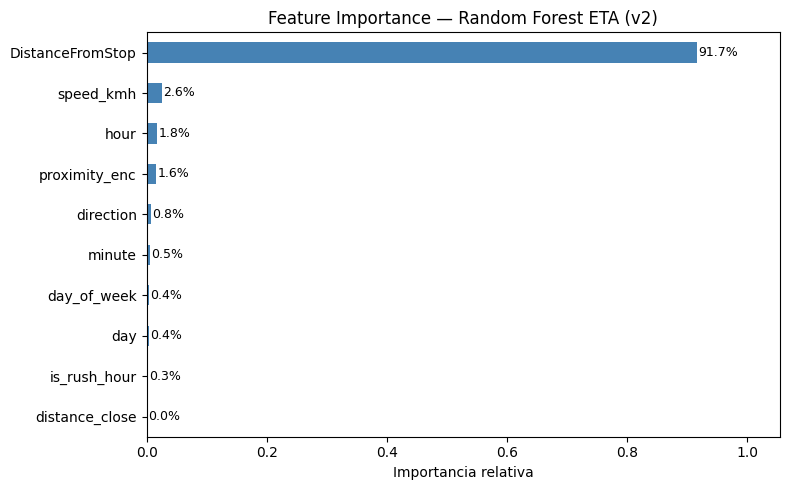

Gráfico guardado como 'feature_importance_eta_v2.png'


In [38]:
# ── CELDA 21: NUEVA — feature importance (para la tesis) ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia relativa')
ax.set_title('Feature Importance — Random Forest ETA (v2)')
ax.set_xlim(0, importances.max() * 1.15)

# Etiquetas con el porcentaje en cada barra
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_eta_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'feature_importance_eta_v2.png'")

In [39]:
#usar estos datos para definir rush_hour mas arriba

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crear DataFrame con predicciones, valores reales, y la hora de cada registro
error_analysis = pd.DataFrame({
    'y_real':    y_test.values,
    'y_pred':    y_pred,
    'hour':      X_test['hour'].values,
    'day_of_week': X_test['day_of_week'].values
})

# Error absoluto por fila
error_analysis['abs_error'] = abs(error_analysis['y_real'] - error_analysis['y_pred'])

# MAE agrupado por hora del día
mae_por_hora = error_analysis.groupby('hour')['abs_error'].mean()

# MAE agrupado por día de la semana (0=lunes, 6=domingo)
mae_por_dia = error_analysis.groupby('day_of_week')['abs_error'].mean()

print("MAE por hora del día (en minutos):")
print(mae_por_hora.round(4))

print("\nMAE por día de la semana:")
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
for i, val in mae_por_dia.items():
    print(f"  {dias[i]}: {val:.4f} min")

# Guardar para incluir en la tesis
mae_por_hora.to_csv('mae_por_hora.csv')
mae_por_dia.to_csv('mae_por_dia.csv')

MAE por hora del día (en minutos):
hour
0     0.2135
1     0.1981
2     0.1838
3     0.2009
4     0.1913
5     0.2180
6     0.2505
7     0.3296
8     0.3566
9     0.3474
10    0.3156
11    0.3175
12    0.3240
13    0.3270
14    0.3438
15    0.3593
16    0.3998
17    0.4291
18    0.4162
19    0.3425
20    0.2831
21    0.2618
22    0.2407
23    0.2295
Name: abs_error, dtype: float64

MAE por día de la semana:
  Lunes: 0.3361 min
  Martes: 0.3441 min
  Miércoles: 0.3500 min
  Jueves: 0.3481 min
  Viernes: 0.3452 min
  Sábado: 0.2788 min
  Domingo: 0.2555 min


In [40]:
# ── CELDA 22: sin cambios — guardar modelo ────────────────────────────────────
model_filename = 'rf_model_eta_v2.pkl'
joblib.dump(rf_model, model_filename)

# NUEVO: también guardamos la lista de features para usarla en producción
# El microservicio Flask necesita saber exactamente qué features espera
import pickle
with open('rf_features_eta_v2.pkl', 'wb') as f:
    pickle.dump(features, f)

print(f"Modelo guardado: '{model_filename}'")
print(f"Features guardadas: 'rf_features_eta_v2.pkl'")
print(f"\nFeatures del modelo: {features}")

Modelo guardado: 'rf_model_eta_v2.pkl'
Features guardadas: 'rf_features_eta_v2.pkl'

Features del modelo: ['DistanceFromStop', 'speed_kmh', 'proximity_enc', 'hour', 'direction', 'minute', 'is_rush_hour', 'day_of_week', 'distance_close', 'day']
